# 케라스 백엔드를 파이토치로 설정하기

In [1]:
# ⚠️ 이 코드가 keras 임포트보다 항상 먼저 와야 합니다!
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
import torch

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.backend.backend()}") # 이 부분이 'torch'로 나와야 합니다.
print(f"PyTorch version: {torch.__version__}")

Keras version: 3.11.2
Keras backend: torch
PyTorch version: 2.7.1+cu118


## 29일 머신러닝 및 RNN 이론, 딥러닝은 이론 및 실습 문제

In [20]:
# 작업 준비
import numpy as np
import pandas as pd
# 데이터 분할
from sklearn.model_selection import train_test_split
# 모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, SimpleRNN, \
    LSTM, GRU, BatchNormalization, Flatten
from keras.optimizers import Adam, RMSprop, SGD
from keras.losses import categorical_crossentropy, binary_crossentropy, \
    sparse_categorical_crossentropy, mean_squared_error
# 모델 학습
from keras.callbacks import EarlyStopping, ModelCheckpoint
# 모델 로드
from keras.models import load_model
# 성능 검토
# from keras.metrics import R2Score, RootMeanSquaredError # 다소 어려운 구간임
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error
from keras.utils import to_categorical

from keras.applications import VGG16

In [ ]:
#사용
#전처리기(함수)-일차 가이드를 주자
#이미지는 크기는 알맞게 단채널로 들어온다
#1. /255 
#전처리기
def 전처리기(이미지):
    전처리된_이미지=이미지/255
    return np.array[전처리된_이미지]
완성된_모델=l_m
#후처리기
def 후처리기(모델의_출력):
    정답=np.array(['티셔츠_상의','바지','풀오버','드레스','코트','샌들','셔츠','운동화','가방','앵클' '부츠'])
    디코딩된_결과=정답[np.argmax(모델의_출력)]
    return 디코딩된_결과

In [ ]:
def 완성된_예측기(입력_이미지):
    전처리된_이미지=전처리기(입력_이미지)
    완성된_모델.predict(전처리된_이미지)
    결과=후처리기(출력)

### 완성된 모델로 이미지 예측기를 만드시오(과제-월요일(8.25)까지)
1. 전처리 내용
2. 모델선정 검증
3. 후처리 내용
4. 예측기의 함수는 1개로 통합

In [3]:
from keras.datasets import mnist, fashion_mnist

In [4]:
(X,y), (_,_) = fashion_mnist.load_data()
X.shape, y.shape

((60000, 28, 28), (60000,))

In [14]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
#사용
#전처리기(함수)-일차 가이드를 주자
#이미지는 크기는 알맞게 단채널로 들어온다
#전처리기
def preprocessing(img):
    pre_img=img/255
    return np.array[pre_img]
# 완성된_모델=l_m

#후처리기
def process(output):
    labels=np.array(['티셔츠_상의','바지','풀오버','드레스','코트','샌들','셔츠','운동화','가방','앵클' '부츠'])
    decode_answer=labels[np.argmax(output)]
    return decode_answer

In [10]:
from keras.applications import VGG16

# VGG16

In [5]:
m = Sequential()
m.add(Input(shape=(224,224,3)))
m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D())
m.add(Conv2D(128, 3, 1, padding='same', activation='relu'))
m.add(Conv2D(128, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D())
m.add(Conv2D(256, 3, 1, padding='same', activation='relu'))
m.add(Conv2D(256, 3, 1, padding='same', activation='relu'))
m.add(Conv2D(256, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D())
m.add(Conv2D(512, 3, 1, padding='same', activation='relu'))
m.add(Conv2D(512, 3, 1, padding='same', activation='relu'))
m.add(Conv2D(512, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D())
m.add(Conv2D(512, 3, 1, padding='same', activation='relu'))
m.add(Conv2D(512, 3, 1, padding='same', activation='relu'))
m.add(Conv2D(512, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D())
m.add(Flatten())
m.add(Dense(4096, activation='relu'))
m.add(Dense(4096, activation='relu'))
m.add(Dense(1000, activation='softmax'))
m.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

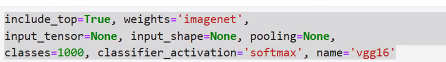

In [ ]:
include_top=True, weights='imagenet',
input_tensor=None, input_shape=None, pooling=None,
classes=1000, classfier_activation='softmax', name='vgg16'

In [3]:
from keras.datasets import cifar10

In [4]:
(x,y), (tt_x,tt_y) = cifar10.load_data()

In [7]:
tr_x, val_x, tr_y, val_y = train_test_split(x, y, test_size=.2)
tr_x.shape, tt_x.shape, val_x.shape

((40000, 32, 32, 3), (10000, 32, 32, 3), (10000, 32, 32, 3))

In [9]:
e_tr_y = to_categorical(tr_y)
e_tr_y.shape

(40000, 10)

In [11]:
m=VGG16(include_top=False, input_shape=(32,32,3),classes=10)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [12]:
m.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
vgg_16 = m

In [15]:
m=Sequential()
m.add(Input(shape=(32,32,3)))
m.add(vgg_16)
m.add(Flatten())
m.add(Dense(10, activation='softmax'))
m.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,818 (56.15 MB)

 Trainable params: 14,719,818 (56.15 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
vgg_16.layers

[<InputLayer name=input_layer_1, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [24]:
len(vgg_16.layers)

19

In [19]:
vgg_16.layers[1]

<Conv2D name=block1_conv1, built=True>

In [21]:
print(vgg_16.layers[1].trainable)
vgg_16.layers[1].trainable = False
print(vgg_16.layers[1].trainable)

True
False


In [ ]:
for i in range(len(vgg_16.layers)):
    vgg_16.layers[i].trainable = False # 해당 레이어는 학습을 안할 것임
for i in range(len(vgg_16.layers)):
    print(vgg_16.layers[i].trainable)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


In [26]:
vgg_16_1 = VGG16(include_top=False, input_shape=(32,32,3),classes=10)
m = Sequential()
m.add(Input(shape=(32,32,3)))
m.add(vgg_16_1)
m.add(Flatten())
m.add(Dense(10, activation='softmax'))
m.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,818 (56.15 MB)

 Trainable params: 14,719,818 (56.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
m.layers[0].trainable = False # 해당 레이어의 학습을 동결

In [28]:
for i in m.layers:
    print(i.trainable)

False
True
True


In [29]:
m.compile(loss='sparse_categorical_crossentropy', metrics=['acc'])

In [ ]:
# 위에서 vgg16모델을 동결시켰으므로 5130개의 파라미터만 학습을 진행하게 됨
m.fit(tr_x, tr_y, epochs=10)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - acc: 0.4428 - loss: 6.4576
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - acc: 0.5479 - loss: 3.9934
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - acc: 0.5637 - loss: 3.0822
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - acc: 0.5611 - loss: 2.6180
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - acc: 0.5587 - loss: 2.3894
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - acc: 0.5588 - loss: 2.2892
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - acc: 0.5561 - loss: 2.2186
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - acc: 0.5542 - loss: 2.2025
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - acc: 0.5545 - loss: 2.1841
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - acc: 0.5552 - loss: 2.1824


위에선 학습의 정보량이 부족했음을 알 수 있음

In [17]:
m.layers

[<Functional name=vgg16, built=True>,
 <Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>]

In [16]:
m.predict(tr_x)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step


array([[9.87241507e-01, 1.03079798e-02, 2.38022092e-03, ...,
        6.57180834e-08, 1.50140690e-22, 3.89574699e-16],
       [4.26999643e-29, 9.99963760e-01, 3.62229839e-05, ...,
        4.50637968e-39, 3.15089606e-17, 5.18401554e-12],
       [1.48757499e-11, 3.04650050e-04, 9.99642491e-01, ...,
        6.95873445e-19, 1.45510882e-12, 5.28238452e-05],
       ...,
       [2.60354020e-02, 1.37212455e-27, 9.73964572e-01, ...,
        3.23516788e-25, 7.39208343e-24, 3.06451292e-26],
       [9.98063385e-01, 1.19748961e-10, 1.93658972e-03, ...,
        7.44589975e-29, 7.65894946e-26, 1.44351306e-23],
       [1.38816574e-06, 3.63290203e-19, 9.99998569e-01, ...,
        1.51558617e-19, 2.46568645e-26, 2.67648007e-43]], dtype=float32)

In [ ]:
vgg16_2 = VGG16(include_top=False, input_shape=(32,32,3),classes=10)
m = Sequential()
m.add(Input(shape=(32,32,3)))
m.add(vgg16_2)
m.add(Flatten())
m.add(Dense(10, activation='softmax'))
m.summary()

In [ ]:
from keras.optimizers import Adam
adam = Adam(learning_rate=0.0001)

In [ ]:
m.compile(optimizer=adam, loss='sparse_categorical_crossentropy', metrics=['acc'])
m.fit(tr_x, tr_y, epochs=10)

In [21]:
# all_ck = VGG16(include_top=False, input_shape=(32,32,3))
# all_ck.trainable = False
# print(i for i in all_ck.tra)
# m=Sequential()
# n = 0
# for i in all_ck.layers:
#     if n>14:
#         i.trainable=True
#     m.add(i)
#     n+=1

In [40]:
from keras.datasets import fashion_mnist
(_,_), (X, y) = fashion_mnist.load_data()
X = X.reshape(-1,28,28,1)
y = to_categorical(y)
X.shape, y.shape

((10000, 28, 28, 1), (10000, 10))

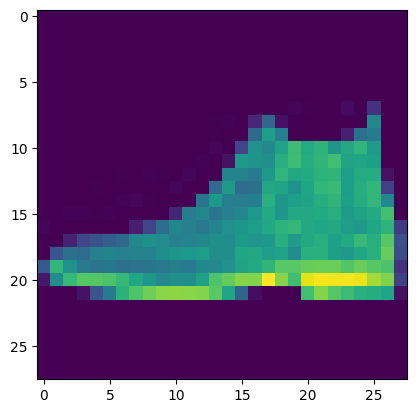

In [37]:
import matplotlib.pyplot as plt
plt.imshow(X[0])

In [38]:
m=Sequential()
m.add(Input(shape=(28,28,1)))
m.add(Conv2D(3,3,padding='same'))
m.add(MaxPooling2D())
m.add(Conv2D(6,3,padding='same'))
m.add(MaxPooling2D())
m.add(Flatten())
m.add(Dense(10, activation='softmax'))
m.compile(loss='categorical_crossentropy', metrics=['acc'])

In [27]:
m.layers[0].weights[0] # 가중치, 1은 편향(bias)
# (28,28,1)(3,3,1,3)

<Variable path=sequential_8/conv2d_32/kernel, shape=(3, 3, 1, 3), dtype=float32, value=[[[[-0.07769033 -0.09230727 -0.09926781]]

  [[ 0.22860831 -0.12028641 -0.18816575]]

  [[-0.32308283 -0.04529446  0.4013813 ]]]


 [[[-0.4015847  -0.29421473  0.15075934]]

  [[ 0.3407902  -0.09590793  0.14933008]]

  [[-0.04810703  0.14473641 -0.12004629]]]


 [[[-0.03058857  0.1623559  -0.10945168]]

  [[ 0.31701064 -0.07444686 -0.10767969]]

  [[ 0.10811859 -0.1159932   0.38939178]]]]>

In [ ]:
m.layers[2].weights[0]
# (14,14,3)(3,3,3,6) -> (14,14,6)

<Variable path=sequential_8/conv2d_33/kernel, shape=(3, 3, 3, 6), dtype=float32, value=[[[[ 5.01289368e-02  1.68088049e-01  1.35242939e-04  4.26006317e-03
     2.23407179e-01 -1.02764249e-01]
   [ 1.32951915e-01 -1.35537446e-01 -1.69305444e-01  1.55016243e-01
    -2.57299513e-01  1.69994712e-01]
   [-1.12549558e-01  1.45841092e-01  8.90509784e-02  5.17485142e-02
     6.32916093e-02  1.45346045e-01]]

  [[-1.73388928e-01 -2.49999404e-01  6.26126230e-02 -1.44571364e-02
    -2.27742642e-02 -2.60532379e-01]
   [ 2.34786332e-01  1.89541847e-01  2.50817239e-02 -7.59319216e-02
     2.51988769e-01  1.01166666e-01]
   [ 1.53914154e-01  8.02628994e-02 -2.06238031e-03  8.45611095e-02
    -5.86384535e-03  1.42692268e-01]]

  [[ 2.68400550e-01 -1.58091411e-01  1.56157196e-01  5.93459010e-02
     2.61886179e-01  2.52349257e-01]
   [ 2.40627527e-01  6.42749369e-02 -2.01932311e-01  1.70099229e-01
     2.19592333e-01  2.21060514e-01]
   [ 2.08230853e-01 -2.43709758e-01  4.02516127e-02  2.44710386e-01
 

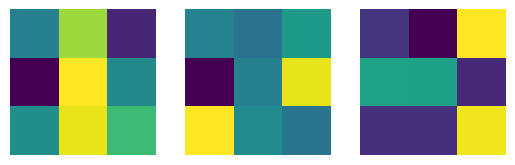

In [ ]:
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(m.layers[0].weights[0].numpy()[:,:,:,i])
    plt.axis('off')
plt.show() # 학습이 안된 형상의 커널 이미지를 확인할 수 있음
# m.layers[0].weights[0].numpy()[:,:,:,0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25040135..0.26840055].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2499994..0.25792372].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2523815..0.24528193].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25978023..0.26648545].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2572995..0.26188618].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.26053238..0.26344].


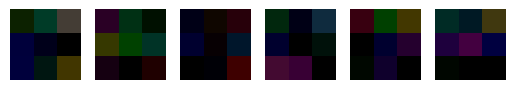

In [ ]:
# 해당 내용은 조금 공부가 필요할 듯. 이해가 부족함;;
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(m.layers[2].weights[0].numpy()[:,:,:,i])
    plt.axis('off')
plt.show()

In [ ]:
from keras.models import Model # 컴퓨터의 케이스를 만든다고 생각하면 됨

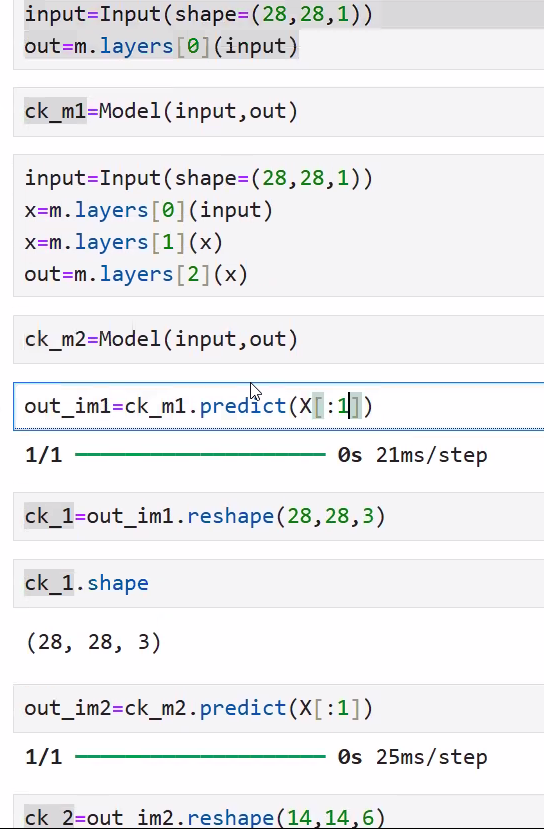

In [60]:
# Model(m.input, m.layers[0].output) # 안됨
input1 = Input(shape=(28,28,1))
output = m.layers[0](input1)
ck_m1 = Model(input1, output)

In [61]:
input1 = Input(shape=(28,28,1))
x = m.layers[0](input1)
x = m.layers[1](x)
output = m.layers[2](x)

In [62]:
ck_m2 = Model(input1, output)

In [63]:
out_im1 = ck_m1.predict(X[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [65]:
out_im2=ck_m2.predict(X[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [66]:
# ck_1 = out_im1.reshape(28,28,3)
ck_2 = out_im2.reshape(14,14,6)
ck_2.shape

(14, 14, 6)

In [67]:
out_im2=ck_m2.predict(X[:1])
out_im2.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


(1, 14, 14, 6)

In [68]:
ck_2=out_im2.reshape(14,14,6)

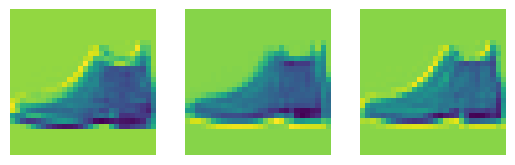

In [56]:
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(ck_1[:,:,i])
    plt.axis('off')

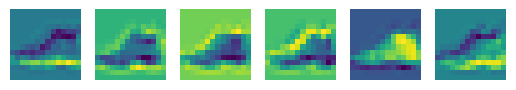

In [69]:
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(ck_2[:,:,i])
    plt.axis('off')

In [72]:
!pip install gdown


   ------------- -------------------------- 1/3 [beautifulsoup4]
   ------------- -------------------------- 1/3 [beautifulsoup4]
   ---------------------------------------- 3/3 [gdown]



In [ ]:
# import gdown
# gdown.download(id='18uC7WTuEXKJDDxbj-Jq6EjzpFrgE7IAd', output='dogs-vs-cats.zip')

Downloading...
From (original): https://drive.google.com/uc?id=18uC7WTuEXKJDDxbj-Jq6EjzpFrgE7IAd
From (redirected): https://drive.google.com/uc?id=18uC7WTuEXKJDDxbj-Jq6EjzpFrgE7IAd&confirm=t&uuid=3f13350a-e13f-4188-83b7-03d035f45582
To: c:\Users\devchoi\Desktop\TIL\2025\Python\dogs-vs-cats.zip
100%|██████████| 852M/852M [00:48<00:00, 17.4MB/s] 


'dogs-vs-cats.zip'

In [76]:
import os, shutil, pathlib

In [84]:
old_dir = pathlib.Path('./dogs-vs-cats/train')
old_dir # 기준 경로를 만들어야함

WindowsPath('dogs-vs-cats/train')

In [85]:
new_dir = pathlib.Path('./dogs-vs-cats_data')

In [90]:
def make_subset(sub_n, s_idx, e_idx):
    for i in ['cat', 'dog']:
        dir=new_dir/sub_n/i
        os.makedirs(dir, exist_ok=True)
        f_ns = [f'{i}.{n}.jpg' for n in range(s_idx, e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n,dst=dir/f_n)

In [ ]:
make_subset('tr_data',0,1000) # 새폴더에 이미지 분류 및 복사

In [ ]:
# # 코랩으로 사용시
# !unzip -qq dogs-vs-cats.zip
# !unzip -qq train.zip

In [93]:
make_subset('tt_data',1000,2000)

In [ ]:
from keras.utils import image_dataset_from_directory # 자동으로 데이터셋을 리사이징 작업하고 데이터셋화를 함 -> 조건은 폴더가 정리되어 있어야 함
tr_ds = image_dataset_from_directory(new_dir/'tr_data',batch_size=32, image_size=(180,180))

Found 2000 files belonging to 2 classes.


In [95]:
tr_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

# 다시 CNN 과제

In [3]:
from keras.datasets import cifar10
(X, y), (_,_) = cifar10.load_data()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.3,random_state=42)
X_train.shape, X_test.shape

((35000, 32, 32, 3), (15000, 32, 32, 3))

In [16]:
cp = ModelCheckpoint('20250819.keras', save_best_only=True)
es = EarlyStopping(patience=3, restore_best_weights=True)

m = Sequential()
m.add(Input(shape=(32,32,3)))
m.add(Conv2D(32, 3, 1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(Conv2D(32, 3, 1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Conv2D(128, 3, 1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(Conv2D(128, 3, 1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(10, activation='softmax'))
m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])
m.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 309,290 (1.18 MB)

 Trainable params: 308,394 (1.18 MB)

 Non-trainable params: 896 (3.50 KB)

In [17]:
hy = m.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[cp, es])

Epoch 1/100
875/875 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - acc: 0.4820 - loss: 1.5975 - val_acc: 0.5917 - val_loss: 1.2442
Epoch 2/100
875/875 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - acc: 0.6606 - loss: 0.9938 - val_acc: 0.6406 - val_loss: 1.0962
Epoch 3/100
875/875 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - acc: 0.7315 - loss: 0.7744 - val_acc: 0.6987 - val_loss: 0.9491
Epoch 4/100
875/875 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - acc: 0.7842 - loss: 0.6267 - val_acc: 0.7143 - val_loss: 0.8997
Epoch 5/100
875/875 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - acc: 0.8223 - loss: 0.5092 - val_acc: 0.7231 - val_loss: 0.8730
Epoch 6/100
875/875 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - acc: 0.8619 - loss: 0.3991 - val_acc: 0.7137 - val_loss: 0.9939
Epoch 7/100
875/875 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - acc: 0.8944 - loss: 0.3011 - val_acc: 0.7343 - val_loss: 1.0178
Epoch 8/100
875/875 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - acc: 0.9184 - loss: 0.2332 - val_acc: 0.7386 - val_loss: 1.0318
